In [1]:
import pandas as pd

# Load dataset
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

# 1. Ukuran dataset
print("=== DATASET SHAPE ===")
print(df.shape)

# 2. Nama kolom
print("\n=== COLUMN NAMES ===")
print(df.columns.tolist())

# 3. Informasi dataset
print("\n=== DATA INFO ===")
df.info()

# 4. Missing values
print("\n=== MISSING VALUES ===")
print(df.isnull().sum())

# 5. Duplikasi
print("\n=== DUPLICATE ROWS ===")
print(df.duplicated().sum())

# 6. Distribusi Attrition
print("\n=== ATTRITION COUNT ===")
print(df["Attrition"].value_counts())

# 7. Persentase Attrition
print("\n=== ATTRITION PERCENTAGE ===")
print((df["Attrition"].value_counts(normalize=True) * 100).round(2))

=== DATASET SHAPE ===
(1470, 35)

=== COLUMN NAMES ===
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

=== DATA INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 no

In [2]:
# Check unique values for all columns
print("=== UNIQUE VALUES PER COLUMN ===")

for column in df.columns:
    unique_values = df[column].unique()
    print(f"\n{column}:")
    print(f"  Number of unique values: {df[column].nunique()}")
    print(f"  Values: {unique_values[:10]}")

# Check constant columns
print("\n=== CONSTANT COLUMNS ===")

constant_columns = [
    column for column in df.columns
    if df[column].nunique() == 1
]

print(constant_columns)

=== UNIQUE VALUES PER COLUMN ===

Age:
  Number of unique values: 43
  Values: [41 49 37 33 27 32 59 30 38 36]

Attrition:
  Number of unique values: 2
  Values: ['Yes' 'No']

BusinessTravel:
  Number of unique values: 3
  Values: ['Travel_Rarely' 'Travel_Frequently' 'Non-Travel']

DailyRate:
  Number of unique values: 886
  Values: [1102  279 1373 1392  591 1005 1324 1358  216 1299]

Department:
  Number of unique values: 3
  Values: ['Sales' 'Research & Development' 'Human Resources']

DistanceFromHome:
  Number of unique values: 29
  Values: [ 1  8  2  3 24 23 27 16 15 26]

Education:
  Number of unique values: 5
  Values: [2 1 4 3 5]

EducationField:
  Number of unique values: 6
  Values: ['Life Sciences' 'Other' 'Medical' 'Marketing' 'Technical Degree'
 'Human Resources']

EmployeeCount:
  Number of unique values: 1
  Values: [1]

EmployeeNumber:
  Number of unique values: 1470
  Values: [ 1  2  4  5  7  8 10 11 12 13]

EnvironmentSatisfaction:
  Number of unique values: 4
  Value

In [3]:
# Remove columns with constant values
columns_to_drop = [
    "EmployeeCount",
    "Over18",
    "StandardHours"
]

df_clean = df.drop(columns=columns_to_drop)

print("Original shape :", df.shape)
print("Cleaned shape  :", df_clean.shape)

print("\nRemoved columns:")
print(columns_to_drop)

Original shape : (1470, 35)
Cleaned shape  : (1470, 32)

Removed columns:
['EmployeeCount', 'Over18', 'StandardHours']


In [4]:
# Check cleaned dataset
print("\n=== CLEANED DATASET INFO ===")
print(df_clean.shape)

print("\n=== MISSING VALUES ===")
print(df_clean.isnull().sum().sum())

print("\n=== DUPLICATE ROWS ===")
print(df_clean.duplicated().sum())

print("\n=== REMAINING COLUMNS ===")
print(df_clean.columns.tolist())


=== CLEANED DATASET INFO ===
(1470, 32)

=== MISSING VALUES ===
0

=== DUPLICATE ROWS ===
0

=== REMAINING COLUMNS ===
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


=== ATTRITION SUMMARY ===
Attrition
No     1233
Yes     237
Name: count, dtype: int64

=== ATTRITION PERCENTAGE ===
Attrition
No     83.88
Yes    16.12
Name: proportion, dtype: float64


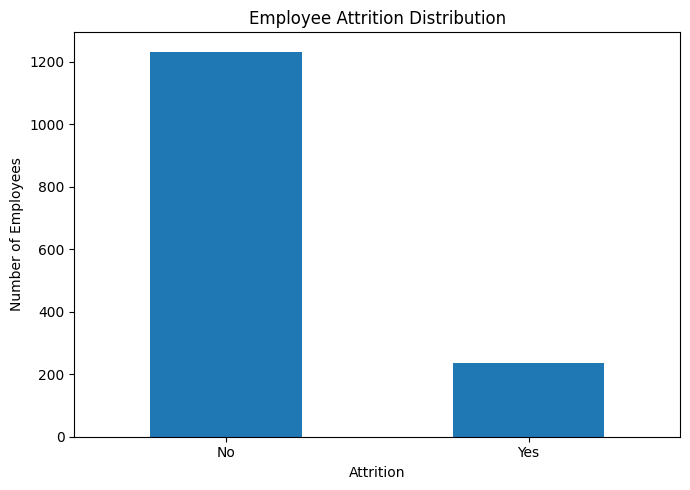

In [5]:
import matplotlib.pyplot as plt

# Attrition count
attrition_count = df_clean["Attrition"].value_counts()

# Attrition percentage
attrition_percentage = (
    df_clean["Attrition"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("=== ATTRITION SUMMARY ===")
print(attrition_count)

print("\n=== ATTRITION PERCENTAGE ===")
print(attrition_percentage)

# Visualization
plt.figure(figsize=(7, 5))

attrition_count.plot(kind="bar")

plt.title("Employee Attrition Distribution")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

=== ATTRITION RATE BY DEPARTMENT ===
Department
Sales                     20.63
Human Resources           19.05
Research & Development    13.84
Name: Attrition, dtype: float64


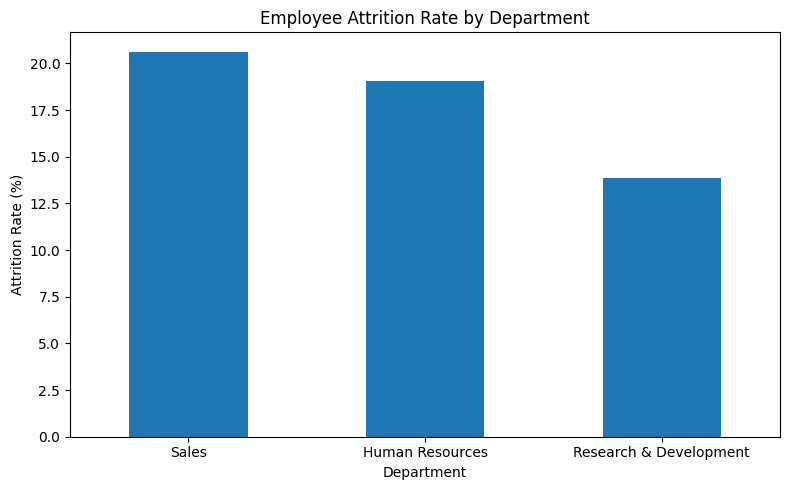

In [6]:
# Attrition rate by department

department_attrition = (
    df_clean.groupby("Department")["Attrition"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .round(2)
    .sort_values(ascending=False)
)

print("=== ATTRITION RATE BY DEPARTMENT ===")
print(department_attrition)

# Visualization
plt.figure(figsize=(8, 5))

department_attrition.plot(kind="bar")

plt.title("Employee Attrition Rate by Department")
plt.xlabel("Department")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

=== ATTRITION RATE BY OVERTIME ===
OverTime
Yes    30.53
No     10.44
Name: Attrition, dtype: float64


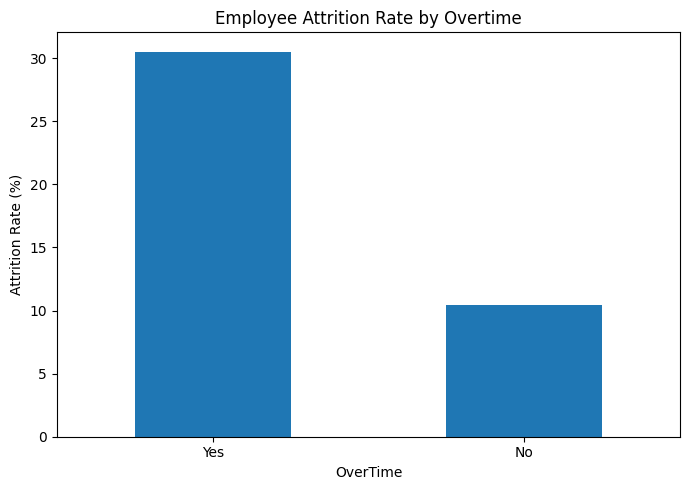

In [7]:
# Attrition rate by overtime

overtime_attrition = (
    df_clean.groupby("OverTime")["Attrition"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .round(2)
    .sort_values(ascending=False)
)

print("=== ATTRITION RATE BY OVERTIME ===")
print(overtime_attrition)

# Visualization
plt.figure(figsize=(7, 5))

overtime_attrition.plot(kind="bar")

plt.title("Employee Attrition Rate by Overtime")
plt.xlabel("OverTime")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

=== ATTRITION RATE BY JOB ROLE ===
JobRole
Sales Representative         39.76
Laboratory Technician        23.94
Human Resources              23.08
Sales Executive              17.48
Research Scientist           16.10
Manufacturing Director        6.90
Healthcare Representative     6.87
Manager                       4.90
Research Director             2.50
Name: Attrition, dtype: float64


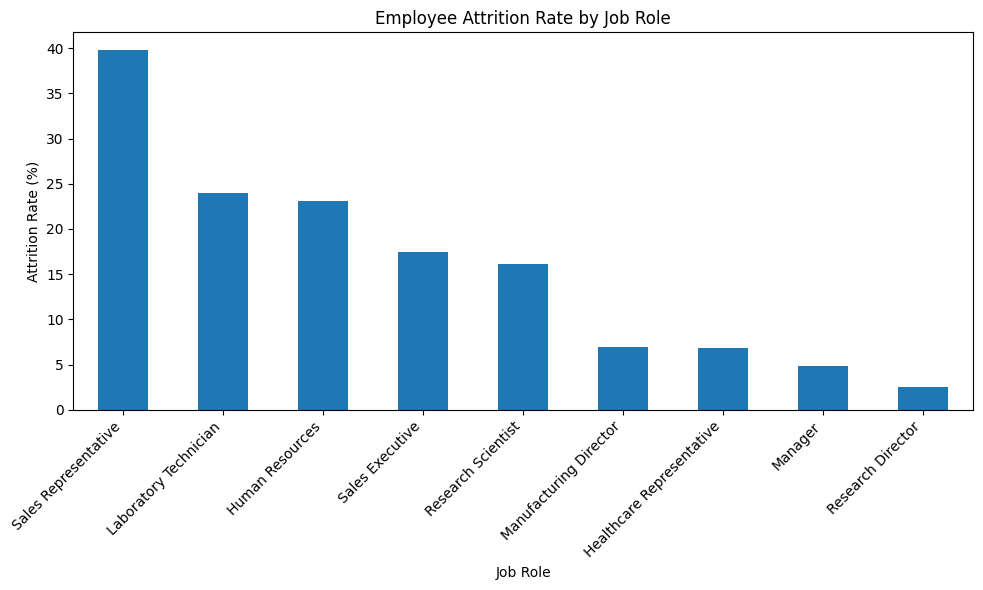

In [8]:
# Attrition rate by job role

job_role_attrition = (
    df_clean.groupby("JobRole")["Attrition"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .round(2)
    .sort_values(ascending=False)
)

print("=== ATTRITION RATE BY JOB ROLE ===")
print(job_role_attrition)

# Visualization
plt.figure(figsize=(10, 6))

job_role_attrition.plot(kind="bar")

plt.title("Employee Attrition Rate by Job Role")
plt.xlabel("Job Role")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

=== ATTRITION RATE BY AGE GROUP ===
AgeGroup
<=25     35.77
26-35    19.14
36-45     9.19
46-55    11.50
56+      17.02
Name: Attrition, dtype: float64


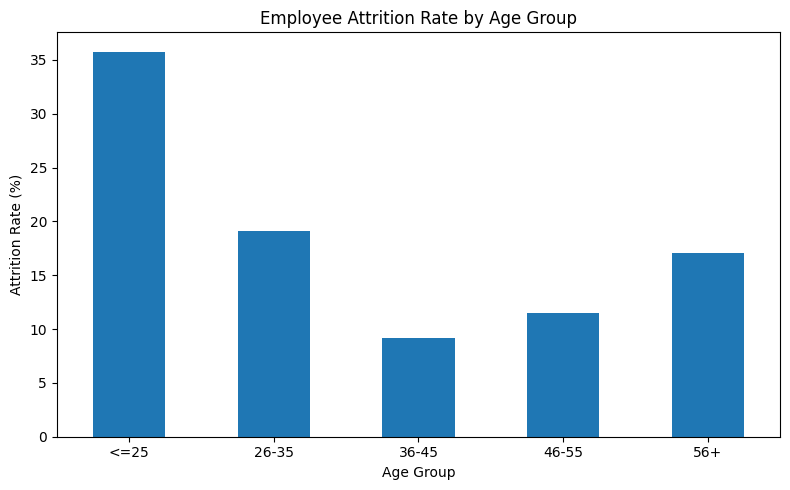

In [9]:
# Create age groups
df_clean["AgeGroup"] = pd.cut(
    df_clean["Age"],
    bins=[0, 25, 35, 45, 55, 100],
    labels=["<=25", "26-35", "36-45", "46-55", "56+"]
)

# Calculate attrition rate by age group
age_attrition = (
    df_clean.groupby("AgeGroup", observed=False)["Attrition"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .round(2)
)

print("=== ATTRITION RATE BY AGE GROUP ===")
print(age_attrition)

# Visualization
plt.figure(figsize=(8, 5))

age_attrition.plot(kind="bar")

plt.title("Employee Attrition Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

=== ATTRITION RATE BY MONTHLY INCOME GROUP ===
IncomeGroup
Low Income             29.27
Lower-Middle Income    14.21
Upper-Middle Income    10.63
High Income            10.33
Name: Attrition, dtype: float64


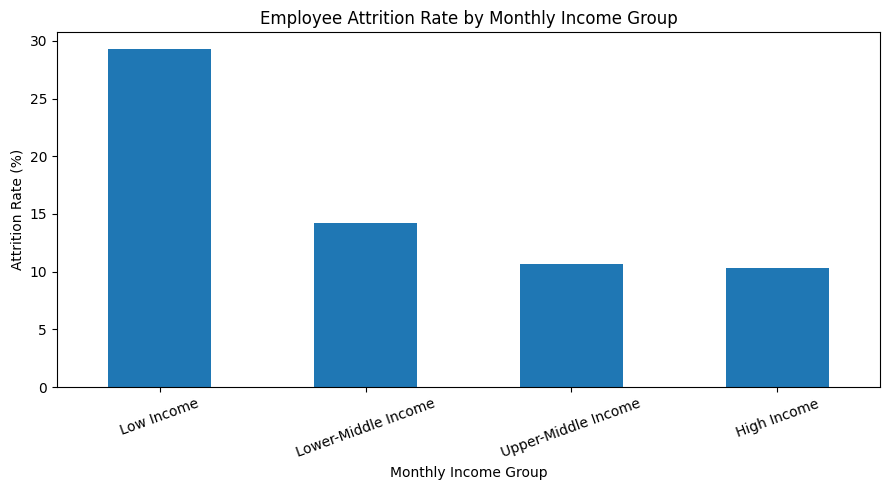

In [10]:
# Attrition rate by monthly income group

df_clean["IncomeGroup"] = pd.qcut(
    df_clean["MonthlyIncome"],
    q=4,
    labels=["Low Income", "Lower-Middle Income", "Upper-Middle Income", "High Income"]
)

income_attrition = (
    df_clean.groupby("IncomeGroup", observed=False)["Attrition"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .round(2)
)

print("=== ATTRITION RATE BY MONTHLY INCOME GROUP ===")
print(income_attrition)

# Visualization
plt.figure(figsize=(9, 5))

income_attrition.plot(kind="bar")

plt.title("Employee Attrition Rate by Monthly Income Group")
plt.xlabel("Monthly Income Group")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

=== ATTRITION RATE BY MONTHLY INCOME GROUP ===
IncomeGroup
Low Income             29.27
Lower-Middle Income    14.21
Upper-Middle Income    10.63
High Income            10.33
Name: Attrition, dtype: float64


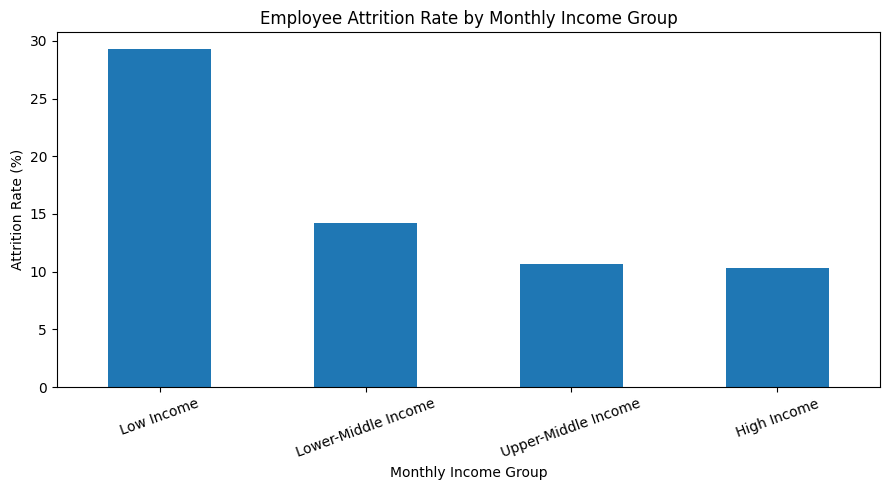

In [11]:
# Attrition rate by monthly income group

df_clean["IncomeGroup"] = pd.qcut(
    df_clean["MonthlyIncome"],
    q=4,
    labels=["Low Income", "Lower-Middle Income", "Upper-Middle Income", "High Income"]
)

income_attrition = (
    df_clean.groupby("IncomeGroup", observed=False)["Attrition"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .round(2)
)

print("=== ATTRITION RATE BY MONTHLY INCOME GROUP ===")
print(income_attrition)

# Visualization
plt.figure(figsize=(9, 5))

income_attrition.plot(kind="bar")

plt.title("Employee Attrition Rate by Monthly Income Group")
plt.xlabel("Monthly Income Group")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

=== ATTRITION RATE BY TENURE ===
TenureGroup
0-2 Years      29.82
3-5 Years      13.82
6-10 Years     12.28
11-20 Years     6.67
20+ Years      12.12
Name: Attrition, dtype: float64


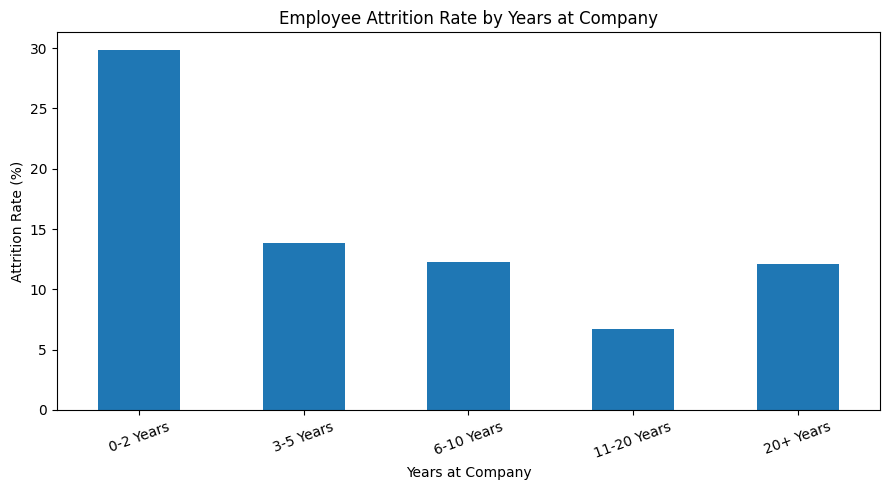

In [12]:
# Create tenure groups

df_clean["TenureGroup"] = pd.cut(
    df_clean["YearsAtCompany"],
    bins=[-1, 2, 5, 10, 20, 100],
    labels=["0-2 Years", "3-5 Years", "6-10 Years", "11-20 Years", "20+ Years"]
)

tenure_attrition = (
    df_clean.groupby("TenureGroup", observed=False)["Attrition"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .round(2)
)

print("=== ATTRITION RATE BY TENURE ===")
print(tenure_attrition)

plt.figure(figsize=(9, 5))

tenure_attrition.plot(kind="bar")

plt.title("Employee Attrition Rate by Years at Company")
plt.xlabel("Years at Company")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

=== ATTRITION RATE BY BUSINESS TRAVEL ===
BusinessTravel
Travel_Frequently    24.91
Travel_Rarely        14.96
Non-Travel            8.00
Name: Attrition, dtype: float64


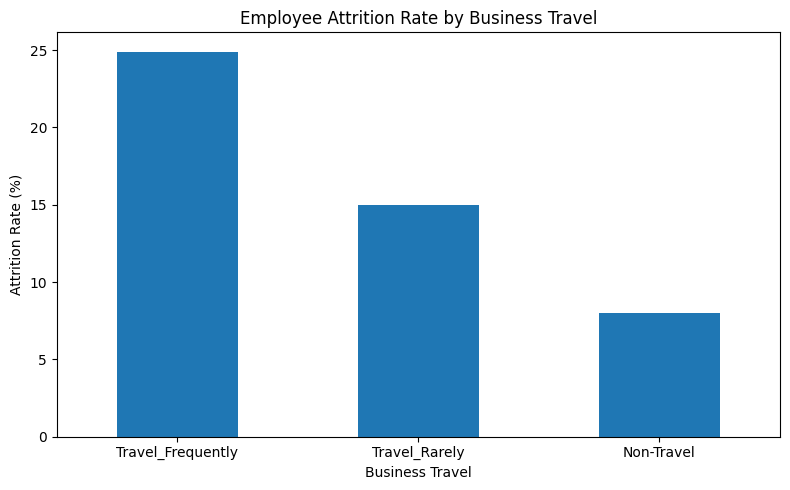

In [13]:
# Attrition rate by business travel

travel_attrition = (
    df_clean.groupby("BusinessTravel")["Attrition"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .round(2)
    .sort_values(ascending=False)
)

print("=== ATTRITION RATE BY BUSINESS TRAVEL ===")
print(travel_attrition)

plt.figure(figsize=(8, 5))

travel_attrition.plot(kind="bar")

plt.title("Employee Attrition Rate by Business Travel")
plt.xlabel("Business Travel")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

=== ATTRITION RATE BY WORK-LIFE BALANCE ===
WorkLifeBalance
1    31.25
2    16.86
3    14.22
4    17.65
Name: Attrition, dtype: float64


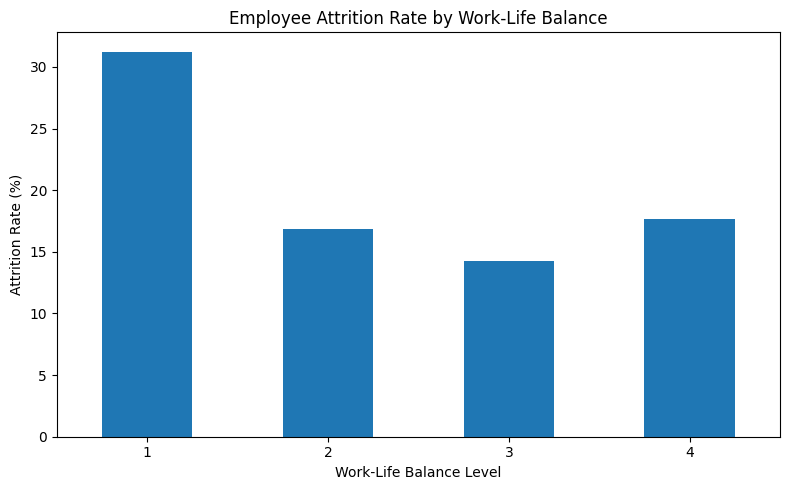

In [14]:
# Attrition rate by work-life balance

worklife_attrition = (
    df_clean.groupby("WorkLifeBalance")["Attrition"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .round(2)
)

print("=== ATTRITION RATE BY WORK-LIFE BALANCE ===")
print(worklife_attrition)

plt.figure(figsize=(8, 5))

worklife_attrition.plot(kind="bar")

plt.title("Employee Attrition Rate by Work-Life Balance")
plt.xlabel("Work-Life Balance Level")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

=== ATTRITION RATE BY JOB LEVEL ===
JobLevel
1    26.34
2     9.74
3    14.68
4     4.72
5     7.25
Name: Attrition, dtype: float64


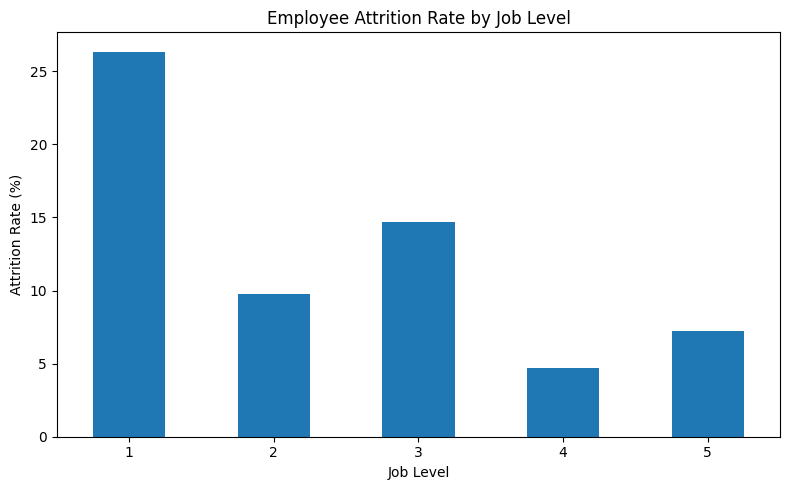

In [15]:
# Attrition rate by job level

joblevel_attrition = (
    df_clean.groupby("JobLevel")["Attrition"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .round(2)
)

print("=== ATTRITION RATE BY JOB LEVEL ===")
print(joblevel_attrition)

plt.figure(figsize=(8, 5))

joblevel_attrition.plot(kind="bar")

plt.title("Employee Attrition Rate by Job Level")
plt.xlabel("Job Level")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

=== ATTRITION RATE BY DISTANCE FROM HOME ===
DistanceGroup
1-5 km      13.77
6-10 km     14.47
11-20 km    20.00
20+ km      22.06
Name: Attrition, dtype: float64


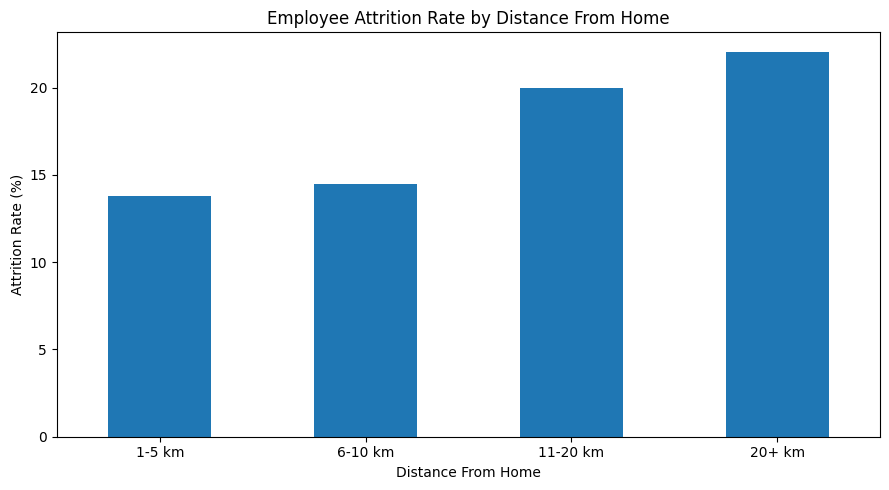

In [16]:
# Create distance groups

df_clean["DistanceGroup"] = pd.cut(
    df_clean["DistanceFromHome"],
    bins=[0, 5, 10, 20, 100],
    labels=["1-5 km", "6-10 km", "11-20 km", "20+ km"]
)

distance_attrition = (
    df_clean.groupby("DistanceGroup", observed=False)["Attrition"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .round(2)
)

print("=== ATTRITION RATE BY DISTANCE FROM HOME ===")
print(distance_attrition)

plt.figure(figsize=(9, 5))

distance_attrition.plot(kind="bar")

plt.title("Employee Attrition Rate by Distance From Home")
plt.xlabel("Distance From Home")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

=== ATTRITION RATE BY STOCK OPTION LEVEL ===
StockOptionLevel
0    24.41
1     9.40
2     7.59
3    17.65
Name: Attrition, dtype: float64


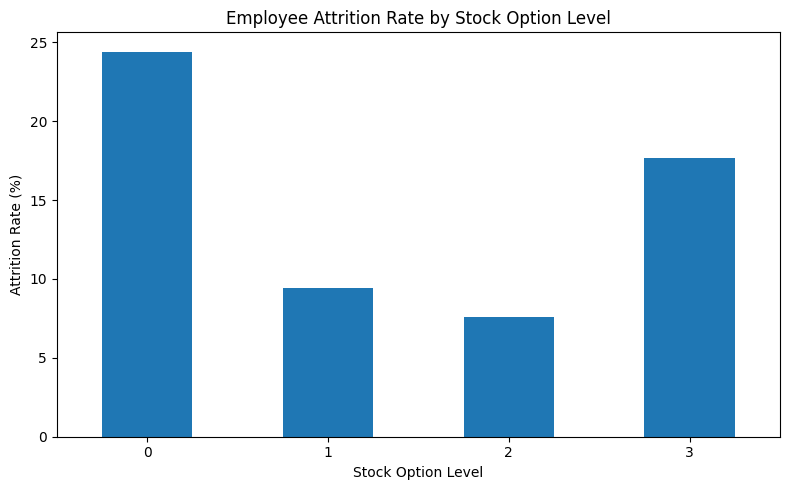

In [17]:
# Attrition rate by stock option level

stock_attrition = (
    df_clean.groupby("StockOptionLevel")["Attrition"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .round(2)
)

print("=== ATTRITION RATE BY STOCK OPTION LEVEL ===")
print(stock_attrition)

plt.figure(figsize=(8, 5))

stock_attrition.plot(kind="bar")

plt.title("Employee Attrition Rate by Stock Option Level")
plt.xlabel("Stock Option Level")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

=== ATTRITION RATE BY GENDER ===
Gender
Female    14.80
Male      17.01
Name: Attrition, dtype: float64


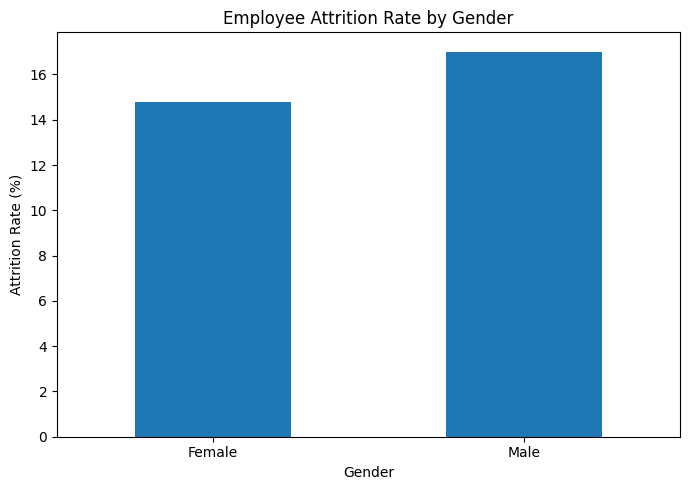

In [18]:
# Attrition rate by gender

gender_attrition = (
    df_clean.groupby("Gender")["Attrition"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .round(2)
)

print("=== ATTRITION RATE BY GENDER ===")
print(gender_attrition)

plt.figure(figsize=(7, 5))

gender_attrition.plot(kind="bar")

plt.title("Employee Attrition Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

=== ATTRITION RATE BY MARITAL STATUS ===
MaritalStatus
Single      25.53
Married     12.48
Divorced    10.09
Name: Attrition, dtype: float64


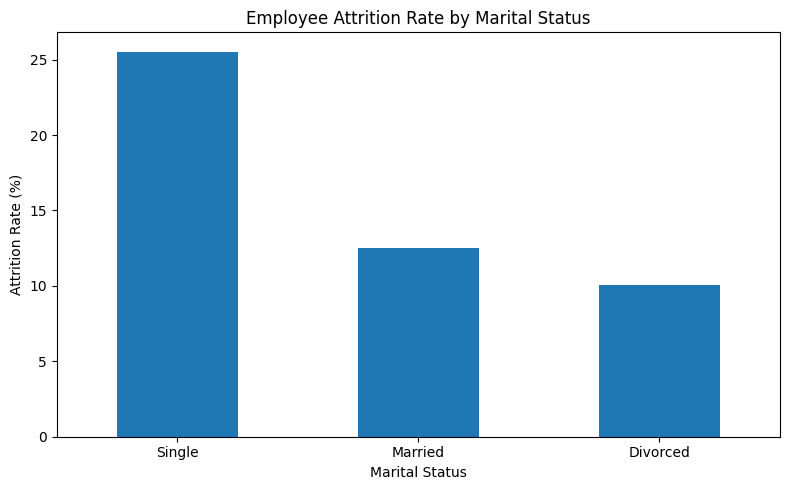

In [19]:
# Attrition rate by marital status

marital_attrition = (
    df_clean.groupby("MaritalStatus")["Attrition"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .round(2)
    .sort_values(ascending=False)
)

print("=== ATTRITION RATE BY MARITAL STATUS ===")
print(marital_attrition)

plt.figure(figsize=(8, 5))

marital_attrition.plot(kind="bar")

plt.title("Employee Attrition Rate by Marital Status")
plt.xlabel("Marital Status")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

=== ATTRITION RATE BY EDUCATION FIELD ===
EducationField
Human Resources     25.93
Technical Degree    24.24
Marketing           22.01
Life Sciences       14.69
Medical             13.58
Other               13.41
Name: Attrition, dtype: float64


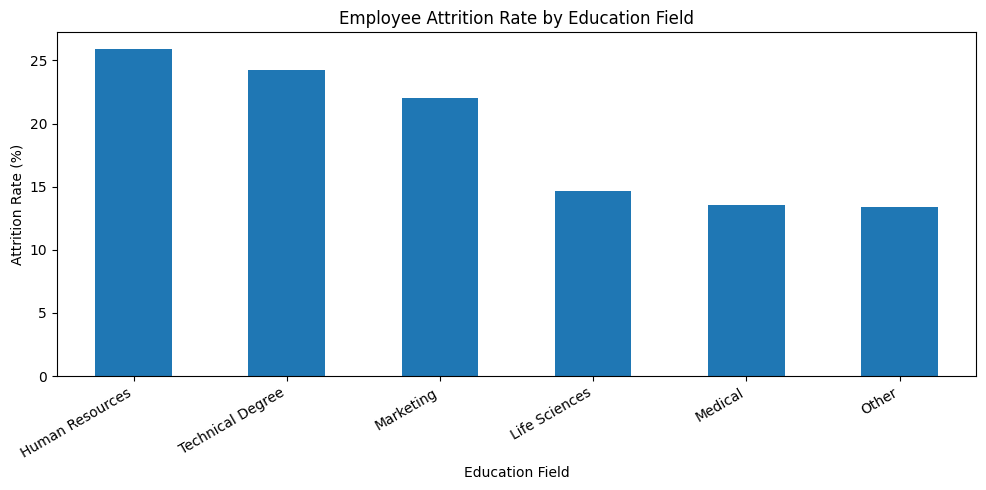

In [20]:
# Attrition rate by education field

education_field_attrition = (
    df_clean.groupby("EducationField")["Attrition"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .round(2)
    .sort_values(ascending=False)
)

print("=== ATTRITION RATE BY EDUCATION FIELD ===")
print(education_field_attrition)

plt.figure(figsize=(10, 5))

education_field_attrition.plot(kind="bar")

plt.title("Employee Attrition Rate by Education Field")
plt.xlabel("Education Field")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()

=== ATTRITION RATE BY ENVIRONMENT SATISFACTION ===
EnvironmentSatisfaction
1    25.35
2    14.98
3    13.69
4    13.45
Name: Attrition, dtype: float64


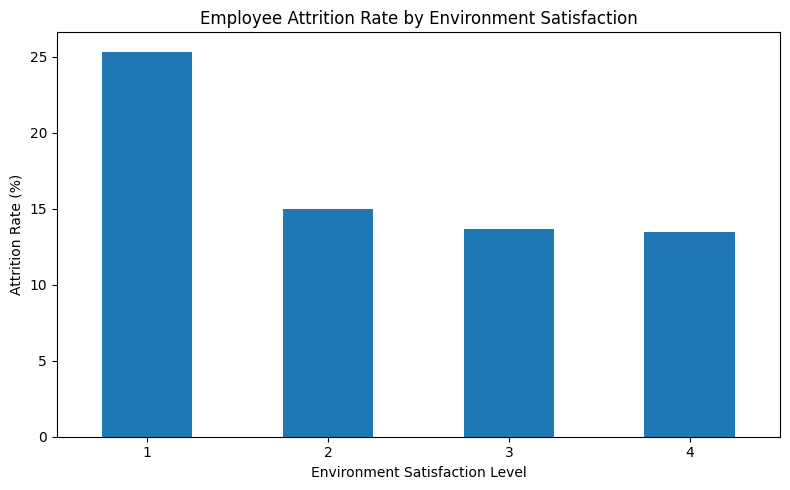

In [21]:
# Attrition rate by environment satisfaction

environment_attrition = (
    df_clean.groupby("EnvironmentSatisfaction")["Attrition"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .round(2)
)

print("=== ATTRITION RATE BY ENVIRONMENT SATISFACTION ===")
print(environment_attrition)

plt.figure(figsize=(8, 5))

environment_attrition.plot(kind="bar")

plt.title("Employee Attrition Rate by Environment Satisfaction")
plt.xlabel("Environment Satisfaction Level")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

=== ATTRITION RATE BY TOTAL WORKING YEARS ===
ExperienceGroup
0-2 Years      43.90
3-5 Years      19.17
6-10 Years     14.99
11-20 Years    11.47
20+ Years       7.73
Name: Attrition, dtype: float64


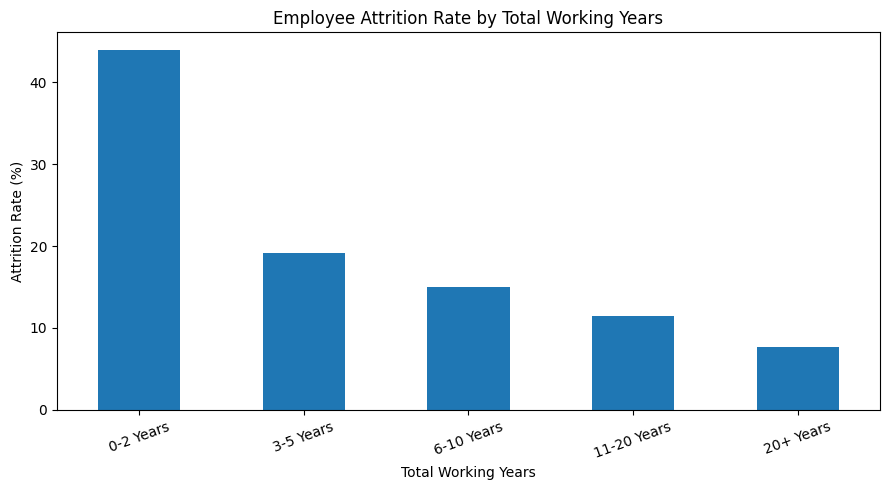

In [22]:
# Create total working years groups

df_clean["ExperienceGroup"] = pd.cut(
    df_clean["TotalWorkingYears"],
    bins=[-1, 2, 5, 10, 20, 40],
    labels=["0-2 Years", "3-5 Years", "6-10 Years", "11-20 Years", "20+ Years"]
)

experience_attrition = (
    df_clean.groupby("ExperienceGroup", observed=False)["Attrition"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .round(2)
)

print("=== ATTRITION RATE BY TOTAL WORKING YEARS ===")
print(experience_attrition)

plt.figure(figsize=(9, 5))

experience_attrition.plot(kind="bar")

plt.title("Employee Attrition Rate by Total Working Years")
plt.xlabel("Total Working Years")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

In [23]:
# Overall attrition summary

total_employees = len(df_clean)
total_attrition = (df_clean["Attrition"] == "Yes").sum()
attrition_rate = (total_attrition / total_employees) * 100

summary = pd.DataFrame({
    "Metric": [
        "Total Employees",
        "Employees with Attrition",
        "Employees Remaining",
        "Overall Attrition Rate"
    ],
    "Value": [
        total_employees,
        total_attrition,
        total_employees - total_attrition,
        round(attrition_rate, 2)
    ]
})

print(summary)

                     Metric    Value
0           Total Employees  1470.00
1  Employees with Attrition   237.00
2       Employees Remaining  1233.00
3    Overall Attrition Rate    16.12


In [24]:
# Save cleaned dataset
df_clean.to_csv("hr_employee_attrition_cleaned.csv", index=False)

print("Cleaned dataset saved successfully.")
print("Shape:", df_clean.shape)

Cleaned dataset saved successfully.
Shape: (1470, 37)
